# Lunar Lander Experiments: Evidence for Conclusions

This notebook is organized around the eight project conclusions. Each conclusion has one or two targeted graphs that directly support the statement.

The notebook compares PID, bang-bang, RL fuel, and RL smooth controllers. It also compares the current bang-bang controller against the older constant-acceleration approximation.


In [153]:
import importlib
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import constants
import controller
import integrator
import physics
import rl_agent
import simulation

for module in (constants, controller, integrator, physics, rl_agent, simulation):
    importlib.reload(module)

from constants import (
    DRY_MASS,
    DT,
    EXHAUST_VELOCITY,
    INITIAL_ALTITUDE,
    INITIAL_MASS,
    INITIAL_VELOCITY,
    MAX_THRUST,
    MOON_GRAVITY,
    SAFE_LANDING_SPEED,
)
from controller import BangBangController, PIDController
from integrator import step
from physics import fuel_remaining
from rl_agent import QLearningController, SmoothQLearningController
from simulation import check_landing_status, clamp_to_ground

METHOD = "rk4"
MAX_STEPS = 15000
TRIALS = 5000
SEED = 7

CONTROLLERS = ["pid", "bang_bang", "rl_fuel", "rl_smooth"]
LABELS = {
    "pid": "PID",
    "bang_bang": "Bang-bang",
    "bang_bang_old": "Bang-bang old approx.",
    "rl_fuel": "RL fuel",
    "rl_smooth": "RL smooth",
}
COLORS = {
    "pid": "tab:blue",
    "bang_bang": "tab:orange",
    "bang_bang_old": "tab:brown",
    "rl_fuel": "tab:green",
    "rl_smooth": "tab:red",
}

random.seed(SEED)
np.random.seed(SEED)
print("Local simulator modules reloaded.")


Local simulator modules reloaded.


## Shared Simulation Code

The following cells define the simulation utilities used by every conclusion section.


In [154]:
class OldConstantAccelerationBangBang:
    def __init__(self, safety_margin=0.95):
        self.safety_margin = safety_margin
        self.burning = False

    def reset(self):
        self.burning = False

    def stopping_distance(self, velocity, mass):
        if velocity >= 0:
            return 0.0
        acceleration = MAX_THRUST / mass - MOON_GRAVITY
        if acceleration <= 0:
            return float("inf")
        return velocity * velocity / (2.0 * acceleration)

    def update(self, state, dt):
        altitude, velocity, mass = state
        if self.burning:
            return 1.0
        if self.stopping_distance(velocity, mass) * self.safety_margin >= altitude:
            self.burning = True
            return 1.0
        return 0.0


def load_rl_agents():
    if not Path("q_table.pkl").exists():
        raise FileNotFoundError("q_table.pkl not found. Run: python3 rl_agent.py")
    if not Path("smooth_q_table.pkl").exists():
        raise FileNotFoundError("smooth_q_table.pkl not found. Run: python3 rl_agent.py smooth")
    rl_fuel = QLearningController()
    rl_smooth = SmoothQLearningController()
    rl_fuel.load("q_table.pkl")
    rl_smooth.load("smooth_q_table.pkl")
    return rl_fuel, rl_smooth


rl_fuel_agent, rl_smooth_agent = load_rl_agents()


def make_controller(name, rl_fuel=None, rl_smooth=None):
    if name == "pid":
        return PIDController(kp=0.4, kd=0.5, descent_gain=0.59)
    if name == "bang_bang":
        return BangBangController()
    if name == "bang_bang_old":
        return OldConstantAccelerationBangBang()
    if name == "rl_fuel":
        return rl_fuel
    if name == "rl_smooth":
        return rl_smooth
    raise ValueError(f"Unknown controller: {name}")


def random_initial_state():
    altitude = random.uniform(600.0, 1400.0)
    velocity = random.uniform(-45.0, -5.0)
    mass = random.uniform(INITIAL_MASS * 0.9, INITIAL_MASS * 1.1)
    return [altitude, velocity, max(mass, DRY_MASS + 50.0)]


def throttle_for(name, controller_obj, state):
    if name in ("pid", "bang_bang", "bang_bang_old"):
        return controller_obj.update(state, DT)
    if name in ("rl_fuel", "rl_smooth"):
        if fuel_remaining(state[2]) <= 0:
            return 0.0
        return controller_obj.get_throttle(state)
    raise ValueError(f"Unknown controller: {name}")


def simulate_run(name, initial_state, method=METHOD, record=False, rl_fuel=None, rl_smooth=None):
    controller_obj = make_controller(name, rl_fuel=rl_fuel, rl_smooth=rl_smooth)
    if hasattr(controller_obj, "reset"):
        controller_obj.reset()

    state = initial_state[:]
    time = 0.0
    status = "flying"
    history = []
    previous_throttle = 0.0
    total_throttle_change = 0.0
    sum_squared_throttle_change = 0.0
    max_throttle_change = 0.0
    throttle_change_count = 0

    for _ in range(MAX_STEPS):
        throttle = throttle_for(name, controller_obj, state)
        throttle_change = abs(throttle - previous_throttle)
        total_throttle_change += throttle_change
        sum_squared_throttle_change += throttle_change * throttle_change
        max_throttle_change = max(max_throttle_change, throttle_change)
        if throttle_change > 1e-9:
            throttle_change_count += 1

        if record:
            altitude, velocity, mass = state
            history.append({
                "time": time,
                "altitude": altitude,
                "velocity": velocity,
                "mass": mass,
                "fuel": fuel_remaining(mass),
                "throttle": throttle,
                "throttle_change": throttle_change,
                "acceleration": throttle * MAX_THRUST / mass - MOON_GRAVITY,
            })

        previous_throttle = throttle
        state = clamp_to_ground(step(state, throttle, DT, method))
        time += DT
        status = check_landing_status(state)
        if status != "flying":
            break

    if status == "flying":
        status = "timeout"

    altitude, velocity, mass = state
    result = {
        "controller": name,
        "status": status,
        "time": time,
        "final_speed": abs(velocity),
        "fuel_used": initial_state[2] - mass,
        "fuel_remaining": fuel_remaining(mass),
        "safe": status == "landed" and abs(velocity) <= SAFE_LANDING_SPEED,
        "total_throttle_change": total_throttle_change,
        "avg_throttle_change_per_s": total_throttle_change / time if time > 0 else np.nan,
        "max_throttle_change": max_throttle_change,
        "avg_throttle_jump": total_throttle_change / max(1, throttle_change_count),
        "rms_throttle_change": (sum_squared_throttle_change / max(1, throttle_change_count)) ** 0.5,
        "throttle_change_count": throttle_change_count,
        "initial_altitude": initial_state[0],
        "initial_velocity": initial_state[1],
        "initial_mass": initial_state[2],
    }
    return result, history


def summarize(results, names=None):
    if names is None:
        names = list(results.keys())
    rows = []
    for name in names:
        runs = results[name]
        safe_runs = [run for run in runs if run["safe"]]
        rows.append({
            "controller": LABELS[name],
            "trials": len(runs),
            "success_rate_%": 100.0 * len(safe_runs) / len(runs),
            "crash_rate_%": 100.0 * sum(run["status"] == "crashed" for run in runs) / len(runs),
            "timeout_rate_%": 100.0 * sum(run["status"] == "timeout" for run in runs) / len(runs),
            "avg_fuel_used_kg": np.mean([run["fuel_used"] for run in safe_runs]) if safe_runs else np.nan,
            "avg_landing_speed_m_s": np.mean([run["final_speed"] for run in safe_runs]) if safe_runs else np.nan,
            "avg_time_s": np.mean([run["time"] for run in safe_runs]) if safe_runs else np.nan,
            "avg_max_throttle_change": np.mean([run["max_throttle_change"] for run in safe_runs]) if safe_runs else np.nan,
            "avg_throttle_jump": np.mean([run["avg_throttle_jump"] for run in safe_runs]) if safe_runs else np.nan,
            "avg_rms_throttle_change": np.mean([run["rms_throttle_change"] for run in safe_runs]) if safe_runs else np.nan,
        })
    return rows


def print_table(rows):
    headers = list(rows[0].keys())
    widths = {
        header: max(
            len(header),
            *(len(f"{row[header]:.2f}") if isinstance(row[header], float) else len(str(row[header])) for row in rows)
        )
        for header in headers
    }
    print(" | ".join(header.ljust(widths[header]) for header in headers))
    print("-+-".join("-" * widths[header] for header in headers))
    for row in rows:
        values = []
        for header in headers:
            value = row[header]
            if isinstance(value, float):
                values.append(f"{value:.2f}".rjust(widths[header]))
            else:
                values.append(str(value).ljust(widths[header]))
        print(" | ".join(values))



## Shared Single Run and Monte Carlo Data

The large Monte Carlo experiment is run once and reused throughout the notebook. `TRIALS = 5000` gives stable controller comparisons while still being practical to run locally.


In [155]:
single_initial_state = [INITIAL_ALTITUDE, INITIAL_VELOCITY, INITIAL_MASS]
single_results = {}
single_histories = {}
for name in CONTROLLERS:
    result, history = simulate_run(
        name,
        single_initial_state,
        record=True,
        rl_fuel=rl_fuel_agent,
        rl_smooth=rl_smooth_agent,
    )
    single_results[name] = result
    single_histories[name] = history

print_table(summarize({name: [single_results[name]] for name in CONTROLLERS}, CONTROLLERS))


controller | trials | success_rate_% | crash_rate_% | timeout_rate_% | avg_fuel_used_kg | avg_landing_speed_m_s | avg_time_s | avg_max_throttle_change | avg_throttle_jump | avg_rms_throttle_change
-----------+--------+----------------+--------------+----------------+------------------+-----------------------+------------+-------------------------+-------------------+------------------------
PID        | 1      |         100.00 |         0.00 |           0.00 |            53.89 |                  0.87 |     103.12 |                    0.06 |              0.00 |                    0.00
Bang-bang  | 1      |         100.00 |         0.00 |           0.00 |            21.33 |                  2.96 |      41.76 |                    1.00 |              1.00 |                    1.00
RL fuel    | 1      |         100.00 |         0.00 |           0.00 |            22.73 |                  0.38 |      42.82 |                    1.00 |              1.00 |                    1.00
RL smooth  | 1 

In [156]:
all_monte_carlo_names = CONTROLLERS + ["bang_bang_old"]
initial_states = [random_initial_state() for _ in range(TRIALS)]
mc_results = {name: [] for name in all_monte_carlo_names}

for i, initial_state in enumerate(initial_states):
    for name in all_monte_carlo_names:
        result, _ = simulate_run(
            name,
            initial_state,
            record=False,
            rl_fuel=rl_fuel_agent,
            rl_smooth=rl_smooth_agent,
        )
        mc_results[name].append(result)
    if i % 500 == 0:
        print(f"Completed {i}/{TRIALS} trials")

print(f"Completed {TRIALS}/{TRIALS} trials")


Completed 0/5000 trials
Completed 500/5000 trials
Completed 1000/5000 trials
Completed 1500/5000 trials
Completed 2000/5000 trials
Completed 2500/5000 trials
Completed 3000/5000 trials
Completed 3500/5000 trials
Completed 4000/5000 trials
Completed 4500/5000 trials
Completed 5000/5000 trials


In [157]:
print_table(summarize(mc_results, all_monte_carlo_names))

controller            | trials | success_rate_% | crash_rate_% | timeout_rate_% | avg_fuel_used_kg | avg_landing_speed_m_s | avg_time_s | avg_max_throttle_change | avg_throttle_jump | avg_rms_throttle_change
----------------------+--------+----------------+--------------+----------------+------------------+-----------------------+------------+-------------------------+-------------------+------------------------
PID                   | 5000   |         100.00 |         0.00 |           0.00 |            57.26 |                  0.87 |      94.25 |                    0.72 |              0.00 |                    0.01
Bang-bang             | 5000   |         100.00 |         0.00 |           0.00 |            24.06 |                  2.15 |      30.84 |                    1.00 |              1.00 |                    1.00
RL fuel               | 5000   |         100.00 |         0.00 |           0.00 |            25.13 |                  0.32 |      31.73 |                    1.00 |     

# Conclusion 1: Variable Mass Makes Landing Nonlinear

The spacecraft mass changes continuously as fuel burns. Because thrust acceleration is `T / m`, the same thrust produces larger acceleration as mass decreases.


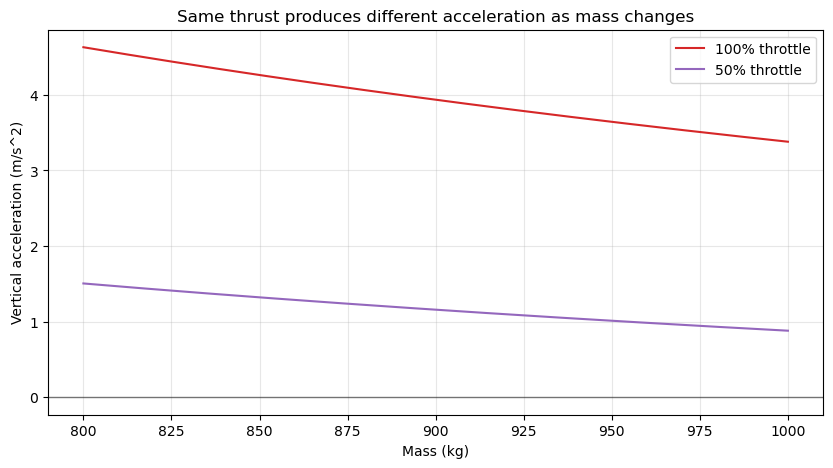

In [158]:
masses = np.linspace(DRY_MASS, INITIAL_MASS, 300)
full_thrust_acceleration = MAX_THRUST / masses - MOON_GRAVITY
half_thrust_acceleration = 0.5 * MAX_THRUST / masses - MOON_GRAVITY

plt.figure(figsize=(10, 5))
plt.plot(masses, full_thrust_acceleration, label="100% throttle", color="tab:red")
plt.plot(masses, half_thrust_acceleration, label="50% throttle", color="tab:purple")
plt.axhline(0, color="black", linewidth=1, alpha=0.5)
plt.xlabel("Mass (kg)")
plt.ylabel("Vertical acceleration (m/s^2)")
plt.title("Same thrust produces different acceleration as mass changes")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


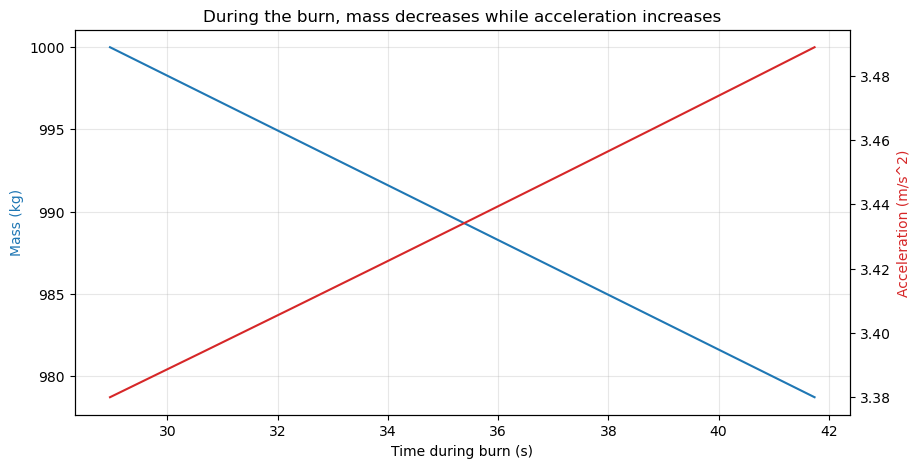

In [159]:
bb_history = single_histories["bang_bang"]
burn_history = [row for row in bb_history if row["throttle"] > 0]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot([row["time"] for row in burn_history], [row["mass"] for row in burn_history], color="tab:blue")
ax2.plot([row["time"] for row in burn_history], [row["acceleration"] for row in burn_history], color="tab:red")
ax1.set_xlabel("Time during burn (s)")
ax1.set_ylabel("Mass (kg)", color="tab:blue")
ax2.set_ylabel("Acceleration (m/s^2)", color="tab:red")
ax1.set_title("During the burn, mass decreases while acceleration increases")
ax1.grid(True, alpha=0.3)
plt.show()


# Conclusion 2: Numerical Integration Affects Simulation Quality

With the normal simulation timestep (`DT = 0.02`), Euler, midpoint/RK2, and RK4 can visually overlap. To make integration error visible, this section uses a fixed-throttle descent problem with a deliberately coarse timestep and compares each method against a fine-step RK4 reference. This isolates numerical integration quality from controller behavior.


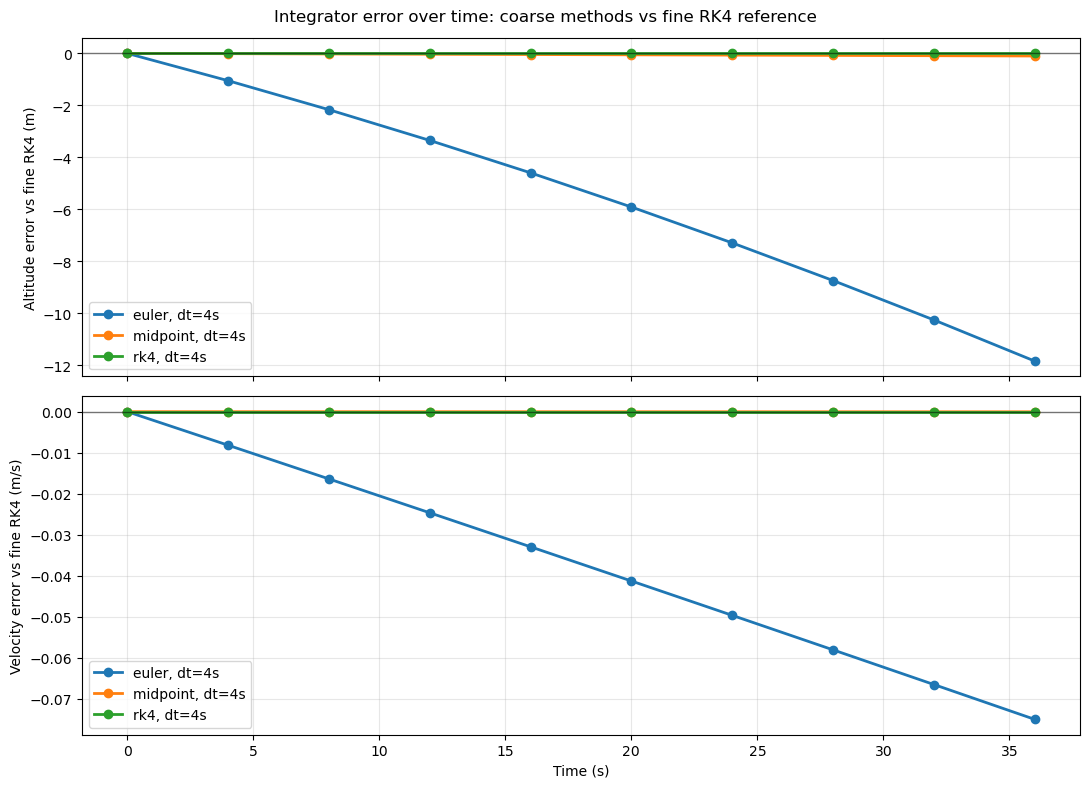

In [160]:
def simulate_fixed_throttle(method, dt, duration=36.0, throttle=0.35):
    state = [1000.0, -20.0, INITIAL_MASS]
    time = 0.0
    history = []

    while time <= duration + 1e-9:
        altitude, velocity, mass = state
        history.append({
            "time": time,
            "altitude": altitude,
            "velocity": velocity,
            "mass": mass,
        })
        state = clamp_to_ground(step(state, throttle, dt, method))
        time += dt

    return history


coarse_dt = 4.0
reference_dt = 0.001
integration_methods = ["euler", "midpoint", "rk4"]
method_histories = {
    method: simulate_fixed_throttle(method, coarse_dt)
    for method in integration_methods
}
reference_history = simulate_fixed_throttle("rk4", reference_dt)

reference_times = np.array([row["time"] for row in reference_history])
reference_altitude = np.array([row["altitude"] for row in reference_history])
reference_velocity = np.array([row["velocity"] for row in reference_history])

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

for method, history in method_histories.items():
    times = np.array([row["time"] for row in history])
    altitude = np.array([row["altitude"] for row in history])
    velocity = np.array([row["velocity"] for row in history])
    altitude_error = altitude - np.interp(times, reference_times, reference_altitude)
    velocity_error = velocity - np.interp(times, reference_times, reference_velocity)

    axes[0].plot(times, altitude_error, marker="o", linewidth=2, label=f"{method}, dt={coarse_dt:g}s")
    axes[1].plot(times, velocity_error, marker="o", linewidth=2, label=f"{method}, dt={coarse_dt:g}s")

axes[0].axhline(0, color="black", linewidth=1, alpha=0.5)
axes[1].axhline(0, color="black", linewidth=1, alpha=0.5)
axes[0].set_ylabel("Altitude error vs fine RK4 (m)")
axes[1].set_ylabel("Velocity error vs fine RK4 (m/s)")
axes[1].set_xlabel("Time (s)")
for axis in axes:
    axis.grid(True, alpha=0.3)
    axis.legend()
fig.suptitle("Integrator error over time: coarse methods vs fine RK4 reference")
plt.tight_layout()
plt.show()


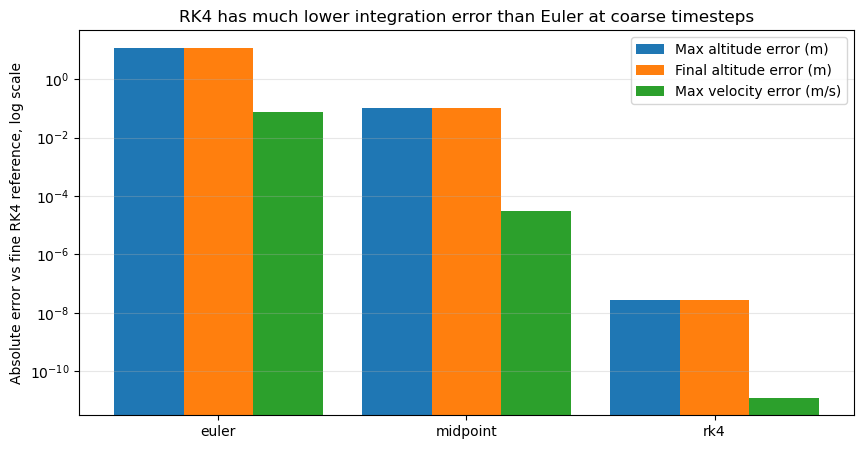

method   | max_altitude_error_m | final_altitude_error_m | max_velocity_error_m_s
---------+----------------------+------------------------+-----------------------
euler    |                11.84 |                  11.84 |                   0.08
midpoint |                 0.10 |                   0.10 |                   0.00
rk4      |                 0.00 |                   0.00 |                   0.00


In [161]:
error_rows = []
for method, history in method_histories.items():
    times = np.array([row["time"] for row in history])
    altitude = np.array([row["altitude"] for row in history])
    velocity = np.array([row["velocity"] for row in history])

    ref_altitude_at_times = np.interp(times, reference_times, reference_altitude)
    ref_velocity_at_times = np.interp(times, reference_times, reference_velocity)

    error_rows.append({
        "method": method,
        "max_altitude_error_m": np.max(np.abs(altitude - ref_altitude_at_times)),
        "final_altitude_error_m": abs(altitude[-1] - ref_altitude_at_times[-1]),
        "max_velocity_error_m_s": np.max(np.abs(velocity - ref_velocity_at_times)),
    })

methods = [row["method"] for row in error_rows]
x = np.arange(len(methods))
width = 0.28

plt.figure(figsize=(10, 5))
plt.bar(x - width, [row["max_altitude_error_m"] for row in error_rows], width, label="Max altitude error (m)")
plt.bar(x, [row["final_altitude_error_m"] for row in error_rows], width, label="Final altitude error (m)")
plt.bar(x + width, [row["max_velocity_error_m_s"] for row in error_rows], width, label="Max velocity error (m/s)")
plt.xticks(x, methods)
plt.yscale("log")
plt.ylabel("Absolute error vs fine RK4 reference, log scale")
plt.title("RK4 has much lower integration error than Euler at coarse timesteps")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.show()

print_table([
    {
        "method": row["method"],
        "max_altitude_error_m": row["max_altitude_error_m"],
        "final_altitude_error_m": row["final_altitude_error_m"],
        "max_velocity_error_m_s": row["max_velocity_error_m_s"],
    }
    for row in error_rows
])


# Conclusion 3: Bang-Bang Uses the Least Fuel

Bang-bang keeps the engine off until the latest feasible burn, so it should minimize fuel relative to smoother feedback controllers.


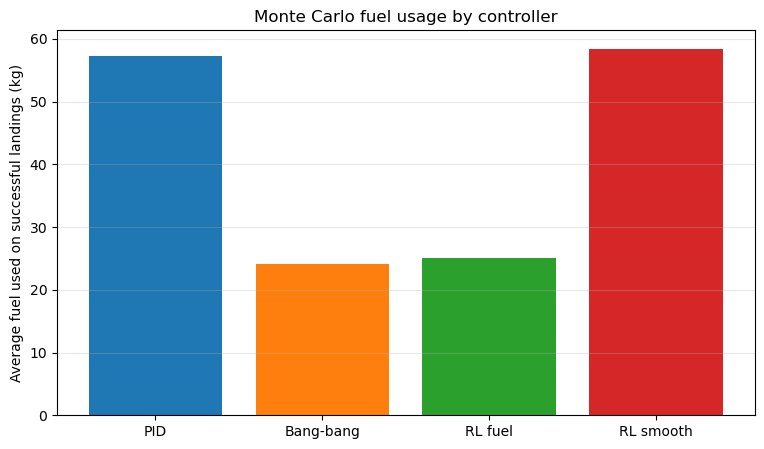

In [162]:
summary_rows = summarize(mc_results, CONTROLLERS)
plt.figure(figsize=(9, 5))
plt.bar([row["controller"] for row in summary_rows], [row["avg_fuel_used_kg"] for row in summary_rows], color=[COLORS[name] for name in CONTROLLERS])
plt.ylabel("Average fuel used on successful landings (kg)")
plt.title("Monte Carlo fuel usage by controller")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


# Conclusion 4: Constant-Acceleration Bang-Bang Was Not Accurate Enough

The old bang-bang trigger assumed constant acceleration. The current controller predicts variable-mass braking using rocket-equation terms, which greatly improves ignition timing.


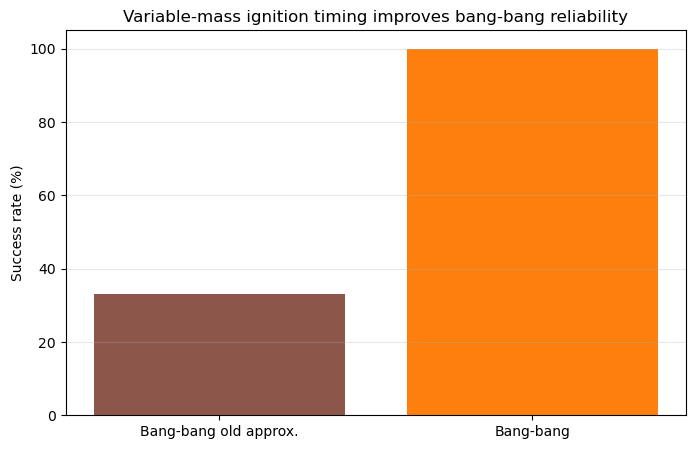

controller            | trials | success_rate_% | crash_rate_% | timeout_rate_% | avg_fuel_used_kg | avg_landing_speed_m_s | avg_time_s | avg_max_throttle_change | avg_throttle_jump | avg_rms_throttle_change
----------------------+--------+----------------+--------------+----------------+------------------+-----------------------+------------+-------------------------+-------------------+------------------------
Bang-bang old approx. | 5000   |          33.18 |        66.82 |           0.00 |            17.70 |                  9.21 |      27.41 |                    1.00 |              1.00 |                    1.00
Bang-bang             | 5000   |         100.00 |         0.00 |           0.00 |            24.06 |                  2.15 |      30.84 |                    1.00 |              1.00 |                    1.00


In [163]:
names = ["bang_bang_old", "bang_bang"]
rows = summarize(mc_results, names)
plt.figure(figsize=(8, 5))
plt.bar([row["controller"] for row in rows], [row["success_rate_%"] for row in rows], color=[COLORS[n] for n in names])
plt.ylabel("Success rate (%)")
plt.ylim(0, 105)
plt.title("Variable-mass ignition timing improves bang-bang reliability")
plt.grid(True, axis="y", alpha=0.3)
plt.show()
print_table(rows)


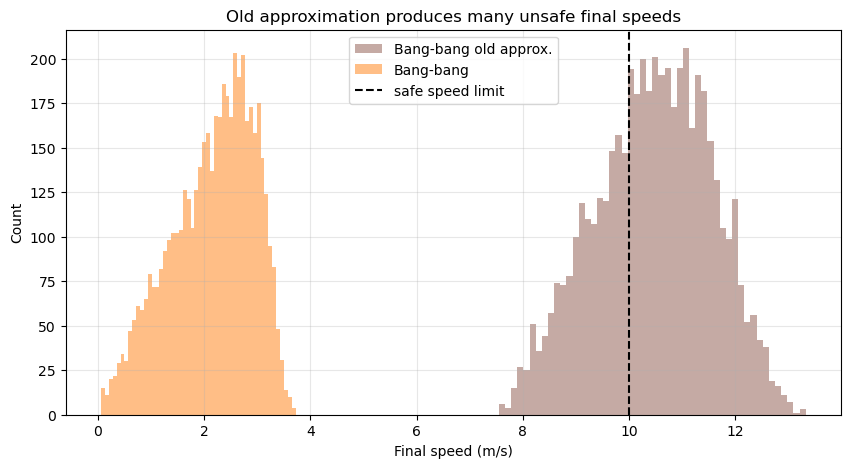

In [164]:
plt.figure(figsize=(10, 5))
for name in names:
    speeds = [run["final_speed"] for run in mc_results[name]]
    plt.hist(speeds, bins=50, alpha=0.5, label=LABELS[name], color=COLORS[name])
plt.axvline(SAFE_LANDING_SPEED, color="black", linestyle="--", label="safe speed limit")
plt.xlabel("Final speed (m/s)")
plt.ylabel("Count")
plt.title("Old approximation produces many unsafe final speeds")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# Conclusion 5: PID Is Smoother but Uses More Fuel Than Bang-Bang

PID applies continuous corrective thrust, producing smoother descent at the cost of more fuel.


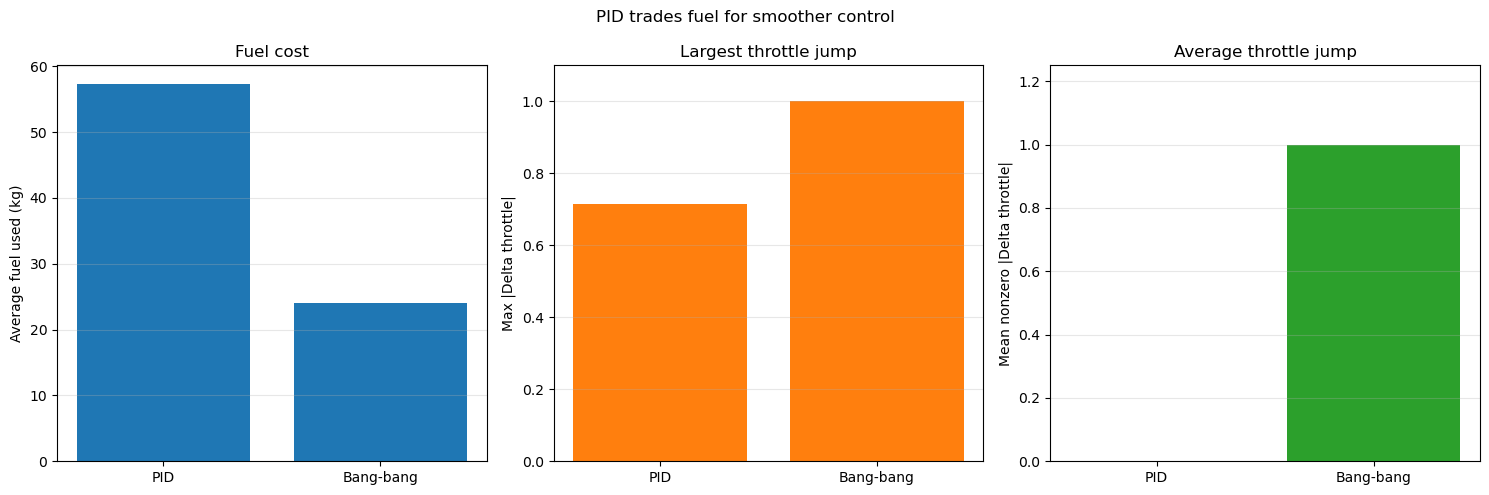

In [165]:
rows = summarize(mc_results, ["pid", "bang_bang"])
labels = [row["controller"] for row in rows]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(labels, [row["avg_fuel_used_kg"] for row in rows], color="tab:blue")
axes[0].set_title("Fuel cost")
axes[0].set_ylabel("Average fuel used (kg)")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(labels, [row["avg_max_throttle_change"] for row in rows], color="tab:orange")
axes[1].set_title("Largest throttle jump")
axes[1].set_ylabel("Max |Delta throttle|")
axes[1].set_ylim(0, 1.1)
axes[1].grid(True, axis="y", alpha=0.3)

avg_jumps = [row["avg_throttle_jump"] for row in rows]
axes[2].bar(labels, avg_jumps, color="tab:green")
axes[2].set_title("Average throttle jump")
axes[2].set_ylabel("Mean nonzero |Delta throttle|")
axes[2].set_ylim(0, max(avg_jumps) * 1.25 if max(avg_jumps) > 0 else 1.0)
axes[2].grid(True, axis="y", alpha=0.3)

for axis in axes:
    for tick in axis.get_xticklabels():
        tick.set_rotation(0)

fig.suptitle("PID trades fuel for smoother control")
plt.tight_layout()
plt.show()


# Conclusion 6: RL Reward Structure Determines Learned Behavior

The fuel-focused RL controller behaves like fuel-efficient bang-bang control. The smoothness-focused RL controller behaves more like PID control.


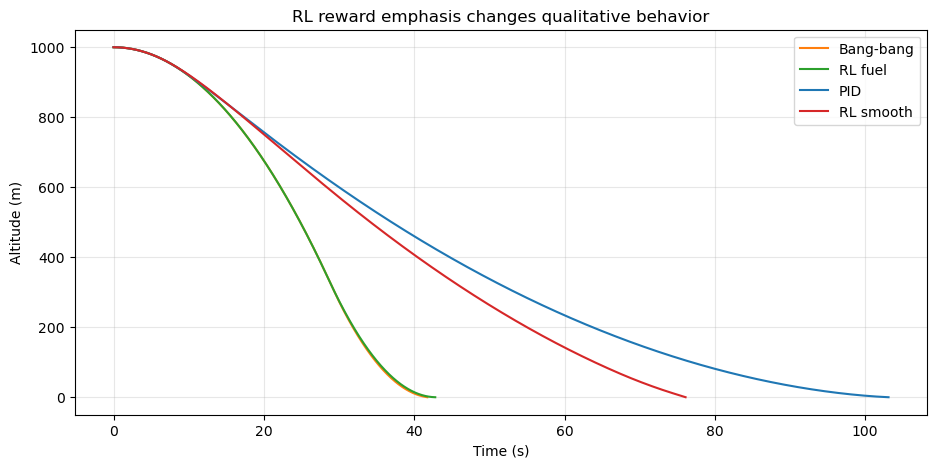

In [166]:
plt.figure(figsize=(11, 5))

for name in ["bang_bang", "rl_fuel", "pid", "rl_smooth"]:
    history = single_histories[name]
    plt.plot(
        [row["time"] for row in history],
        [row["altitude"] for row in history],
        label=LABELS[name],
        color=COLORS[name],
    )

plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.title("RL reward emphasis changes qualitative behavior")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# Conclusion 7: A Single Successful Landing Is Misleading

A controller can look good in one default run but fail or vary under randomized initial conditions. Monte Carlo exposes robustness and sensitivity.


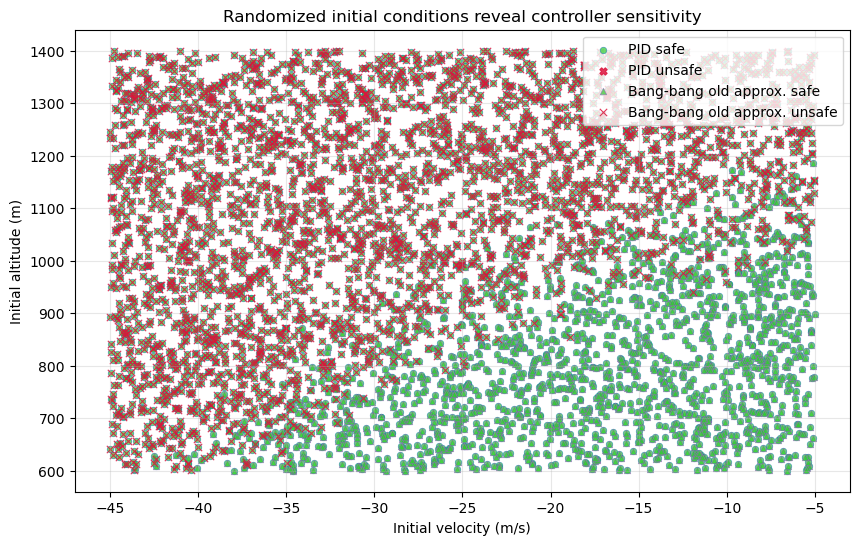

In [167]:
plt.figure(figsize=(10, 6))

plot_styles = {
    "pid": {"safe_marker": "o", "unsafe_marker": "X", "edge": "tab:blue"},
    "bang_bang_old": {"safe_marker": "^", "unsafe_marker": "x", "edge": "tab:purple"},
}

for name in ["pid", "bang_bang_old"]:
    runs = mc_results[name]
    safe_runs = [run for run in runs if run["safe"]]
    unsafe_runs = [run for run in runs if not run["safe"]]
    style = plot_styles[name]

    plt.scatter(
        [run["initial_velocity"] for run in safe_runs],
        [run["initial_altitude"] for run in safe_runs],
        s=22,
        alpha=0.7,
        marker=style["safe_marker"],
        facecolors="limegreen",
        edgecolors=style["edge"],
        linewidths=0.5,
        label=f"{LABELS[name]} safe",
    )
    plt.scatter(
        [run["initial_velocity"] for run in unsafe_runs],
        [run["initial_altitude"] for run in unsafe_runs],
        s=28,
        alpha=0.85,
        marker=style["unsafe_marker"],
        color="crimson",
        linewidths=0.8,
        label=f"{LABELS[name]} unsafe",
    )

plt.xlabel("Initial velocity (m/s)")
plt.ylabel("Initial altitude (m)")
plt.title("Randomized initial conditions reveal controller sensitivity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# Conclusion 8: A Combined Framework Shows Controller Trade-Offs

The final comparison combines numerical simulation, optimal control, feedback control, reinforcement learning, and stochastic evaluation.


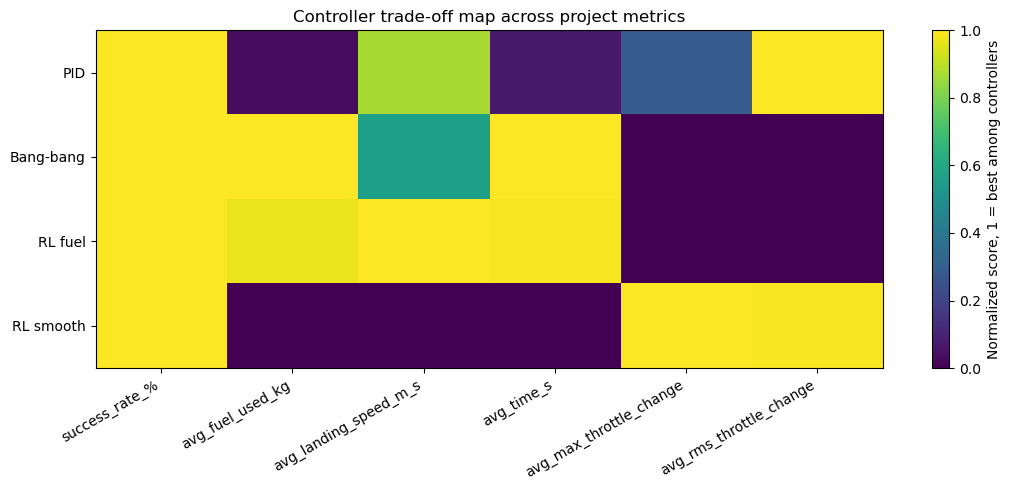

In [168]:
rows = summarize(mc_results, CONTROLLERS)
metrics = [
    ("success_rate_%", "higher"),
    ("avg_fuel_used_kg", "lower"),
    ("avg_landing_speed_m_s", "lower"),
    ("avg_time_s", "lower"),
    ("avg_max_throttle_change", "lower"),
    ("avg_rms_throttle_change", "lower"),
]
score_matrix = []
for row in rows:
    scores = []
    for metric, direction in metrics:
        values = np.array([r[metric] for r in rows], dtype=float)
        value = row[metric]
        if np.nanmax(values) == np.nanmin(values):
            score = 1.0
        elif direction == "higher":
            score = (value - np.nanmin(values)) / (np.nanmax(values) - np.nanmin(values))
        else:
            score = (np.nanmax(values) - value) / (np.nanmax(values) - np.nanmin(values))
        scores.append(score)
    score_matrix.append(scores)

plt.figure(figsize=(11, 5))
plt.imshow(score_matrix, aspect="auto", cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Normalized score, 1 = best among controllers")
plt.yticks(range(len(rows)), [row["controller"] for row in rows])
plt.xticks(range(len(metrics)), [metric[0] for metric in metrics], rotation=30, ha="right")
plt.title("Controller trade-off map across project metrics")
plt.tight_layout()
plt.show()


In [169]:
print_table(rows)

controller | trials | success_rate_% | crash_rate_% | timeout_rate_% | avg_fuel_used_kg | avg_landing_speed_m_s | avg_time_s | avg_max_throttle_change | avg_throttle_jump | avg_rms_throttle_change
-----------+--------+----------------+--------------+----------------+------------------+-----------------------+------------+-------------------------+-------------------+------------------------
PID        | 5000   |         100.00 |         0.00 |           0.00 |            57.26 |                  0.87 |      94.25 |                    0.72 |              0.00 |                    0.01
Bang-bang  | 5000   |         100.00 |         0.00 |           0.00 |            24.06 |                  2.15 |      30.84 |                    1.00 |              1.00 |                    1.00
RL fuel    | 5000   |         100.00 |         0.00 |           0.00 |            25.13 |                  0.32 |      31.73 |                    1.00 |              1.00 |                    1.00
RL smooth  | 50